## Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf

In [3]:
import kagglehub

# Download dataset into current directory
path = kagglehub.dataset_download("nalisha/job-salary-prediction-dataset")

print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\USER\.cache\kagglehub\datasets\nalisha\job-salary-prediction-dataset\versions\1


In [4]:
df = pd.read_csv(r"C:\Users\USER\.cache\kagglehub\datasets\nalisha\job-salary-prediction-dataset\versions\1\job_salary_prediction_dataset.csv")
display(df.head())

print("Dataset Information")
display(df.info())

print("Statistical Summary")
display(df.describe())
display(df.describe(include='object'))

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


None

Statistical Summary


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [5]:
print(df['industry'].unique())
print(df['location'].unique())

['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']


## EDA

### Univariate Analysis

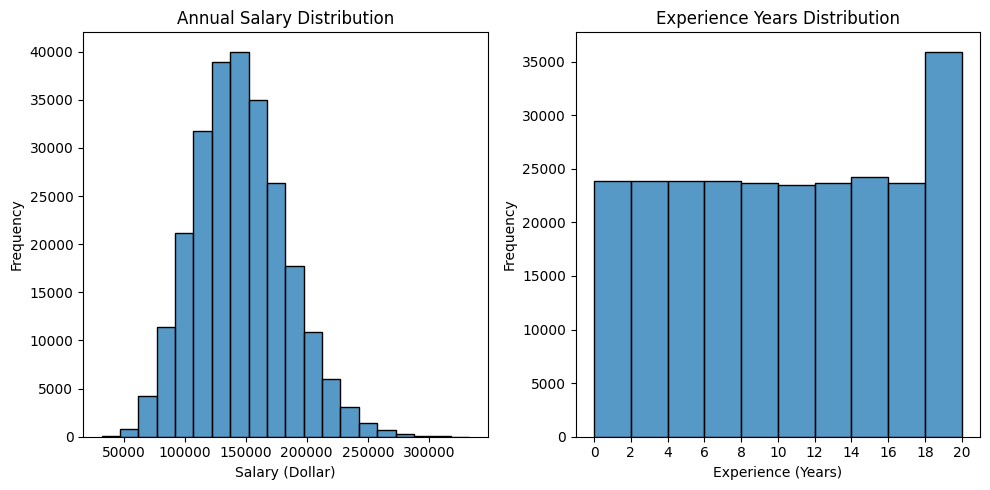

In [6]:
# Numerical Variable EDA
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary'], bins=20)
plt.xlabel("Salary (Dollar)")
plt.ylabel("Frequency")
plt.title("Annual Salary Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df['experience_years'], binwidth=2)
plt.xticks(np.arange(0, 22, 2))
plt.xlabel("Experience (Years)")
plt.ylabel("Frequency")
plt.title("Experience Years Distribution")

plt.tight_layout()
#plt.savefig('./con-univariate')    # Uncomment to save plot
plt.show()


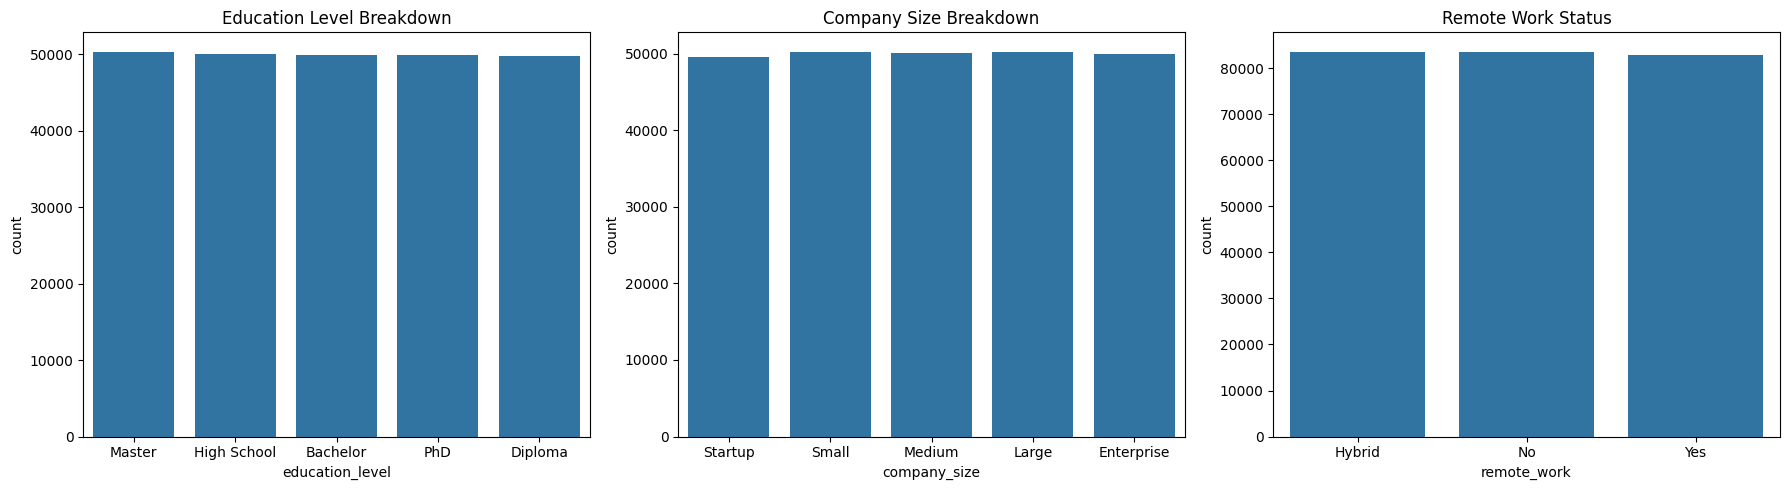

In [7]:
# Categorical Variable EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='education_level', ax=axes[0], order=df['education_level'].value_counts().index)
axes[0].set_title('Education Level Breakdown')

sns.countplot(data=df, x='company_size', ax=axes[1], order=['Startup', 'Small', 'Medium', 'Large', 'Enterprise'])
axes[1].set_title('Company Size Breakdown')

sns.countplot(data=df, x='remote_work', ax=axes[2])
axes[2].set_title('Remote Work Status')

plt.tight_layout()
#plt.savefig('./cat-univariate')    # Uncomment to save plot
plt.show()

### Bivariate Analysis

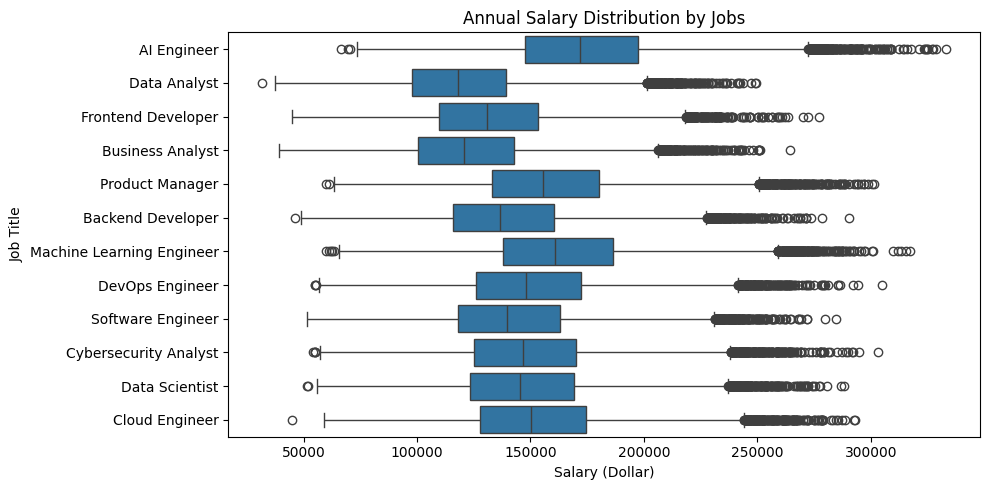

In [8]:
# Boxplot: Salary by Jobs
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='salary', y='job_title')
plt.title("Annual Salary Distribution by Jobs")
plt.xlabel("Salary (Dollar)")
plt.ylabel("Job Title")
plt.tight_layout()
#plt.savefig('./salary-by-jobs')    # Uncomment to save plot
plt.show()

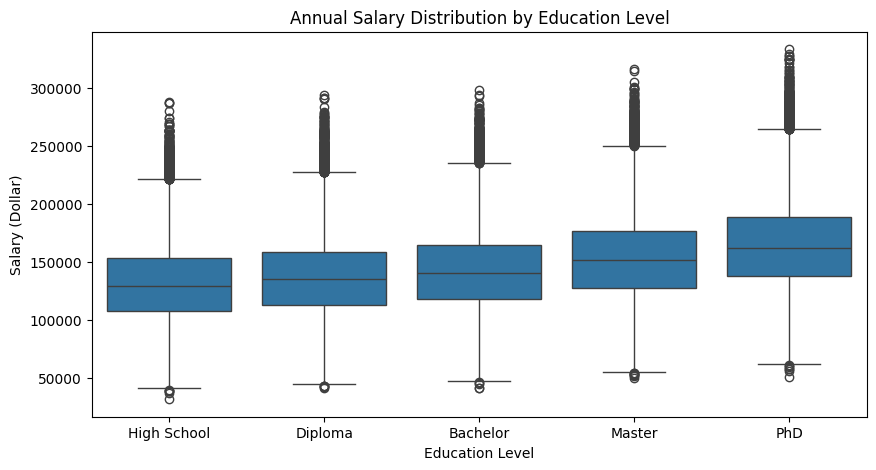

In [9]:
# Boxplot: Salary by Education Level
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='education_level', y='salary', order=['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'])
plt.title('Annual Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary (Dollar)')
#plt.savefig('./salary-education')    # Uncomment to save plot
plt.show()

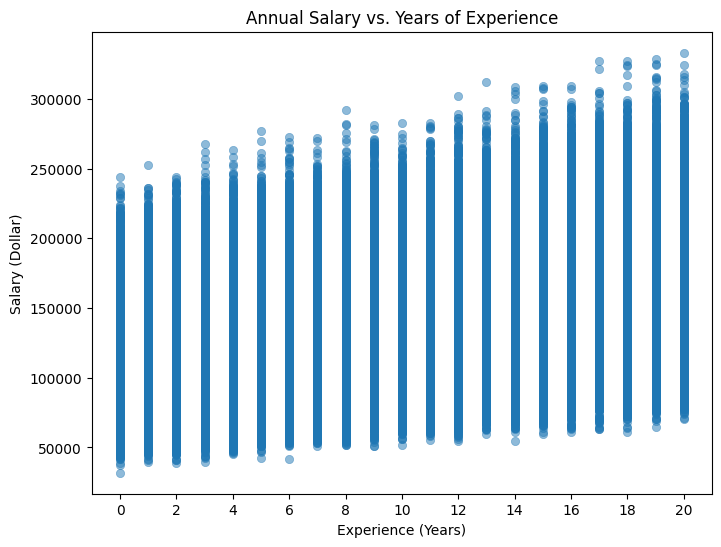

In [10]:
# Scatterplot: Experience vs. Salary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='experience_years', y='salary', alpha=0.5, edgecolor=None)
plt.title('Annual Salary vs. Years of Experience')
plt.xlabel('Experience (Years)')
plt.xticks(np.arange(0, 22, 2))
plt.ylabel('Salary (Dollar)')
#plt.savefig('./salary-experience')    # Uncomment to save plot
plt.show()

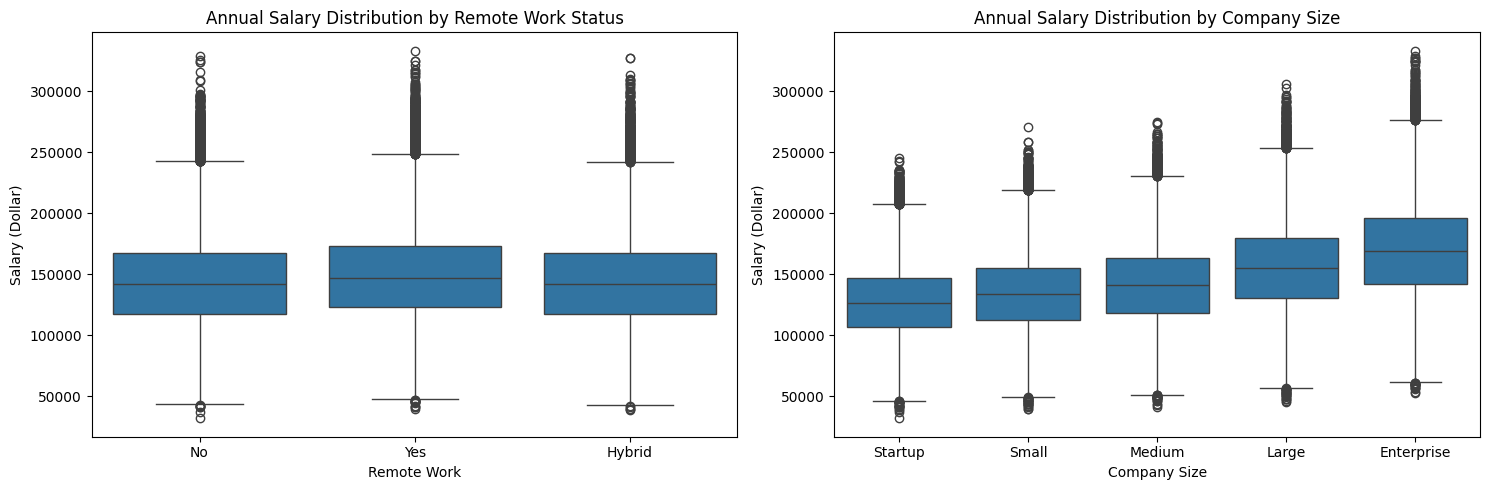

In [11]:
# Boxplot: Salary by Remote Work Status & Salary by Company Size
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='remote_work', y='salary', order=['No', 'Yes', 'Hybrid'])
plt.title('Annual Salary Distribution by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Salary (Dollar)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='company_size', y='salary', order=['Startup', 'Small', 'Medium', 'Large', 'Enterprise'])
plt.title('Annual Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (Dollar)')
plt.tight_layout()
#plt.savefig('./salary-remote_work-company_size')    # Uncomment to save plot
plt.show()

### Multivariate & Correlation Analysis

In [12]:
# Numerical Variables Correlation
numerical_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)

                  experience_years  skills_count  certifications    salary
experience_years          1.000000      0.000149       -0.000198  0.437627
skills_count              0.000149      1.000000       -0.002230  0.127300
certifications           -0.000198     -0.002230        1.000000  0.073819
salary                    0.437627      0.127300        0.073819  1.000000


## Statistical Inference

### Hypothesis Testing

In [13]:
# H(0): Average salary in Tech industry <= Average salary in baseline
# H(A): Average salary in Tech industry > Average salary in baseline

base_salary_avg = df['salary'].mean()
print(f"Baseline Mean Salary: ${base_salary_avg:,.2f} per year")

tech_salary = df[df['industry'] == 'Technology']['salary']
print(f"Tech Industry Mean Salary: ${tech_salary.mean():,.2f} per year")
print(f"Number of Tech Observation: {len(tech_salary)}")

Baseline Mean Salary: $145,718.08 per year
Tech Industry Mean Salary: $145,863.81 per year
Number of Tech Observation: 24903


In [14]:
# One-Sample, Right-Tailed T-Test

t_stat, p_value = stats.ttest_1samp(a=tech_salary, popmean=base_salary_avg, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("There is sufficient evidence to conclude that Technology salaries are significantly higher than the baseline average.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("There is not sufficient evidence to conclude that Technology salaries are significantly higher than the baseline average.")

T-statistic: 0.6162
P-value: 0.2689
Conclusion: Fail to reject the Null Hypothesis (H0).
There is not sufficient evidence to conclude that Technology salaries are significantly higher than the baseline average.


In [15]:
# Confidence Interval
confidence_level = 0.95
degrees_freedom = len(tech_salary) - 1
sample_mean = np.mean(tech_salary)
sample_standard_error = stats.sem(tech_salary)

ci_lower, ci_upper = stats.t.interval(confidence=confidence_level, df=degrees_freedom, loc=sample_mean, scale=sample_standard_error)
print(f"95% Confidence interval of true mean salary for Tech industry lies between:\n${ci_lower:,.2f} and ${ci_upper:,.2f}")


95% Confidence interval of true mean salary for Tech industry lies between:
$145,400.27 and $146,327.34


## Modeling

### Model 1: Simple Linear Regression

In [24]:
# Build Simple Linear Regression Model
formula = 'salary ~ experience_years'
model1 = smf.ols(formula=formula, data=df).fit()
print(model1.summary())
print(f"\nMSE: {model1.mse_resid:.4f}")
print(f"\nRMSE: {model1.mse_resid ** 1/2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                 5.922e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:58:32   Log-Likelihood:            -2.9606e+06
No. Observations:              250000   AIC:                         5.921e+06
Df Residuals:                  249998   BIC:                         5.921e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.187e+05    129.843  

### Model 2: Multiple Linear Regression

In [22]:
# Group job_title into job_field = ['Data & AI', 'Software Development', 'Infrastructure & Security', 'Product & Business']
job_mapping = {
    'Data Analyst': 'Data & AI',
    'Data Scientist': 'Data & AI',
    'Machine Learning Engineer': 'Data & AI',
    'AI Engineer': 'Data & AI',
    'Frontend Developer': 'Software Dev',
    'Backend Developer': 'Software Dev',
    'Software Engineer': 'Software Dev',
    'DevOps Engineer': 'Infra & Security',
    'Cloud Engineer': 'Infra & Security',
    'Cybersecurity Analyst': 'Infra & Security',
    'Business Analyst': 'Product & Business',
    'Product Manager': 'Product & Business'
}

df['job_field'] = df['job_title'].map(job_mapping)
print(df['job_field'].value_counts())

job_field
Data & AI             83234
Software Dev          62634
Infra & Security      62534
Product & Business    41598
Name: count, dtype: int64


In [27]:
# Build Multiple Linear Regression Model
formula = 'salary ~ experience_years + C(job_field) + C(education_level) + C(company_size)'
model2 = smf.ols(formula=formula, data=df).fit()
print(model2.summary())
print(f"\nMSE: {model2.mse_resid:.4f}")
print(f"\nRMSE: {model2.mse_resid ** 1/2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                 1.897e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:28:30   Log-Likelihood:            -2.9062e+06
No. Observations:              250000   AIC:                         5.812e+06
Df Residuals:                  249987   BIC:                         5.813e+06
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Diagnosis (Residual Analysis)

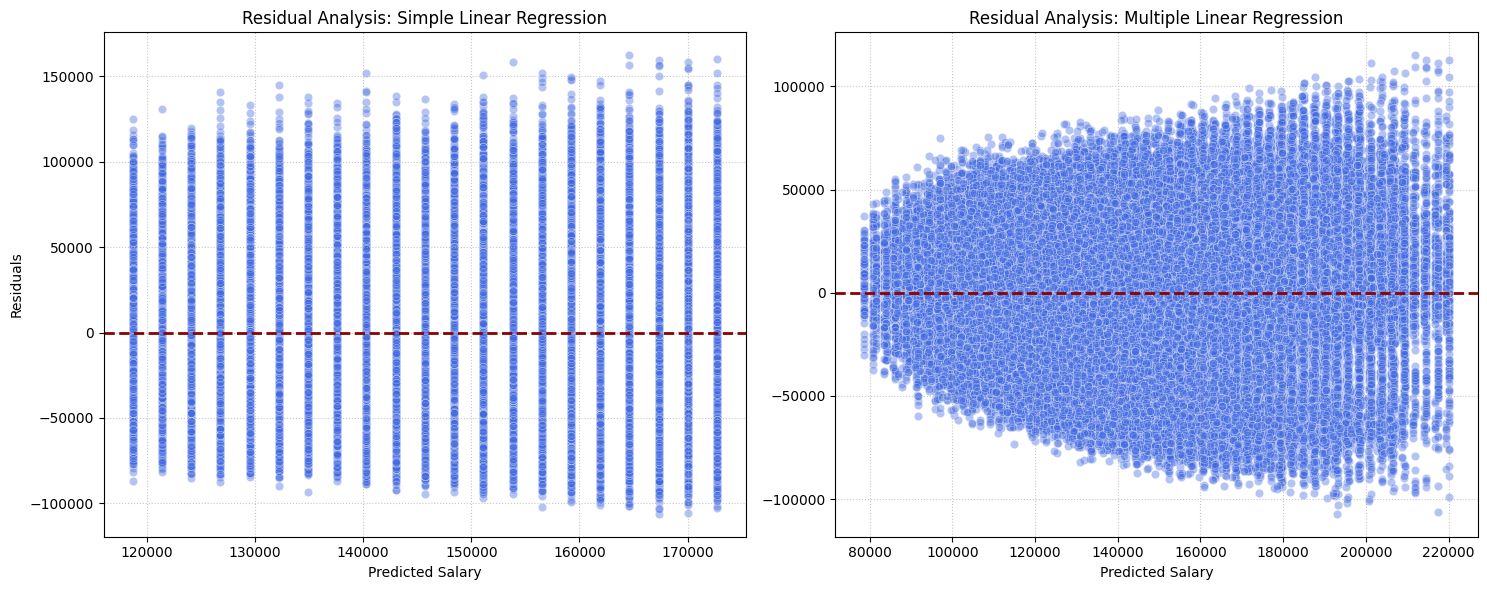

In [ ]:
# Residual Analysis

# Model 1: Simple Linear Regression
predicted_salary1 = model1.predict(df)
residuals1 = model1.resid

# Model 2: Multiple Linear Regression
predicted_salary2 = model2.predict(df)
residuals2 = model2.resid

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=predicted_salary1, y=residuals1, alpha=0.4, color='royalblue')
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=2)
plt.title('Residual Analysis: Simple Linear Regression')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.grid(True, linestyle=':', alpha=0.7)

plt.subplot(1, 2, 2)
sns.scatterplot(x=predicted_salary2, y=residuals2, alpha=0.4, color='royalblue')
plt.axhline(y=0, color='darkred', linestyle='--', linewidth=2)
plt.title('Residual Analysis: Multiple Linear Regression')
plt.xlabel('Predicted Salary')
plt.ylabel(None)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
#plt.savefig('./residual-analysis')    # Uncomment to save plot
plt.show()

### Prediction

Using Multiple Linear Regression

In [46]:
# Constant Baseline for Ceteris Paribus
baseline_exp = df['experience_years'].mean()
baseline_job = df['job_field'].mode()[0]
baseline_edu = df['education_level'].mode()[0]
baseline_size = df['company_size'].mode()[0]

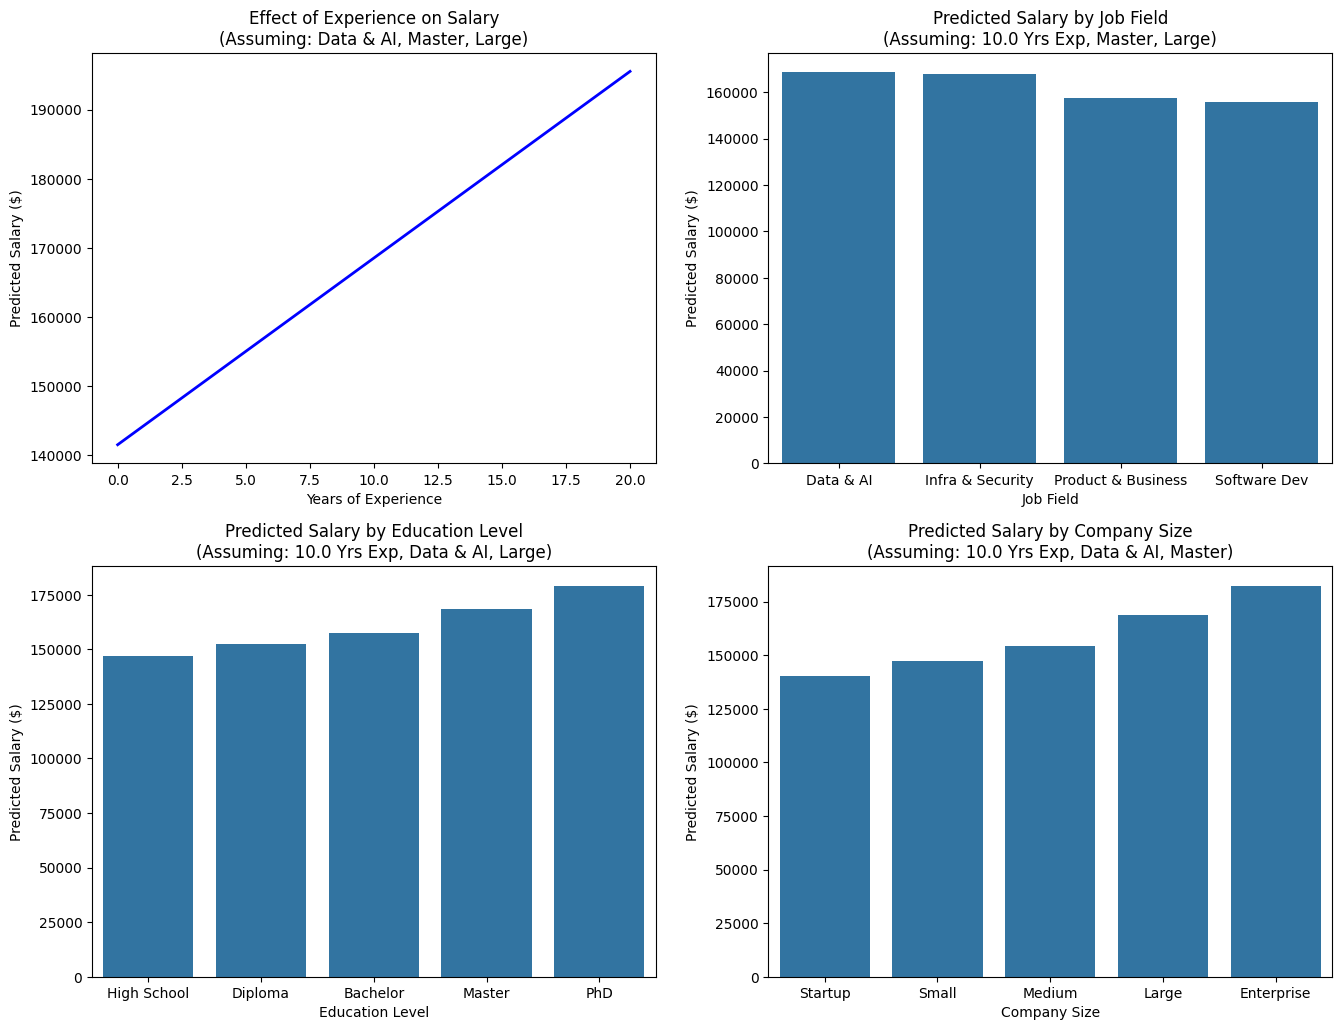

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.25)

# ========== Experience (Years) ==========
exp_range = pd.DataFrame({
    'experience_years': np.linspace(df['experience_years'].min(), df['experience_years'].max(), 50),
    'job_field': baseline_job,
    'education_level': baseline_edu,
    'company_size': baseline_size
})

exp_range['predicted_salary'] = model2.predict(exp_range)

sns.lineplot(data=exp_range, x='experience_years', y='predicted_salary', ax=axes[0, 0], color='blue', linewidth=2)
axes[0, 0].set_title(f'Effect of Experience on Salary\n(Assuming: {baseline_job}, {baseline_edu}, {baseline_size})')
axes[0, 0].set_xlabel('Years of Experience')
axes[0, 0].set_ylabel('Predicted Salary ($)')

# ========== Job Field ==========
job_cats = pd.DataFrame({
    'experience_years': baseline_exp,
    'job_field': df['job_field'].unique(),
    'education_level': baseline_edu,
    'company_size': baseline_size
})
job_cats['predicted_salary'] = model2.predict(job_cats)
job_cats = job_cats.sort_values('predicted_salary', ascending=False)

sns.barplot(data=job_cats, x='job_field', y='predicted_salary', ax=axes[0, 1])
axes[0, 1].set_title(f'Predicted Salary by Job Field\n(Assuming: {baseline_exp:.1f} Yrs Exp, {baseline_edu}, {baseline_size})')
axes[0, 1].set_xlabel('Job Field')
axes[0, 1].set_ylabel('Predicted Salary ($)')

# ========== Education Level ==========
edu_cats = pd.DataFrame({
    'experience_years': baseline_exp,
    'job_field': baseline_job,
    'education_level': df['education_level'].unique(),
    'company_size': baseline_size
})
edu_cats['predicted_salary'] = model2.predict(edu_cats)
edu_cats = edu_cats.sort_values('predicted_salary')

sns.barplot(data=edu_cats, x='education_level', y='predicted_salary', ax=axes[1, 0])
axes[1, 0].set_title(f'Predicted Salary by Education Level\n(Assuming: {baseline_exp:.1f} Yrs Exp, {baseline_job}, {baseline_size})')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Predicted Salary ($)')

# ========== Company Size ==========
size_cats = pd.DataFrame({
    'experience_years': baseline_exp,
    'job_field': baseline_job,
    'education_level': baseline_edu,
    'company_size': df['company_size'].unique()
})
size_cats['predicted_salary'] = model2.predict(size_cats)
orders = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise'] 

sns.barplot(data=size_cats, x='company_size', y='predicted_salary', ax=axes[1, 1], order=orders)
axes[1, 1].set_title(f'Predicted Salary by Company Size\n(Assuming: {baseline_exp:.1f} Yrs Exp, {baseline_job}, {baseline_edu})')
axes[1, 1].set_xlabel('Company Size')
axes[1, 1].set_ylabel('Predicted Salary ($)')

#plt.savefig('./MLR-prediction')    # Uncomment to save plot
plt.show()